# Alfred the Mail Sorting Butler: A LangGraph Example

In this notebook, **we're going to build a complete email processing workflow using LangGraph**.

This notebook is part of the <a href="https://www.hf.co/learn/agents-course">Hugging Face Agents Course</a>, a free course from beginner to expert, where you learn to build Agents.

![Agents course share](https://huggingface.co/datasets/agents-course/course-images/resolve/main/en/communication/share.png)

## What You'll Learn

In this notebook, you'll learn how to:
1. Set up a LangGraph workflow
2. Define state and nodes for email processing
3. Create conditional branching in a graph
4. Connect an LLM for classification and content generation
5. Visualize the workflow graph
6. Execute the workflow with example data

In [1]:
# Install the required packages
%pip install -q langgraph langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


## Setting Up Our Environment

First, let's import all the necessary libraries. LangGraph provides the graph structure, while LangChain offers convenient interfaces for working with LLMs.

In [1]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

# Set your OpenAI API key here
# os.environ["OPENAI_API_KEY"] = "sk-xxxxx"  # Replace with your actual API key

# Initialize our LLM
model = ChatGoogleGenerativeAI(model="models/gemini-3.1-flash-lite", temperature=0)

d:\SBT_Study\SberTechDL\Agents_Course\Unit_2\2_llamaindex\.venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
d:\SBT_Study\SberTechDL\Agents_Course\Unit_2\2_llamaindex\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Define Our State

In LangGraph, **State** is the central concept. It represents all the information that flows through our workflow.

For Alfred's email processing system, we need to track:
- The email being processed
- Whether it's spam or not
- The draft response (for legitimate emails)
- Conversation history with the LLM

In [17]:
class EmailState(TypedDict):
    email: Dict[str, Any]
    is_spam: Optional[bool]
    spam_reason: Optional[str]
    email_category: Optional[str]
    email_draft: Optional[str]
    messages: List[Dict[str, Any]]

## Step 2: Define Our Nodes

In [18]:
def read_email(state: EmailState):
    email = state["email"]
    print(f"Alfred is processing an email from {email['sender']} with subject: {email['subject']}")
    return {}


def classify_email(state: EmailState):
    email = state["email"]

    prompt = f"""
As Alfred the butler of Mr wayne and it's SECRET identity Batman, analyze this email and determine if it is spam or legitimate and should be brought to Mr wayne's attention.
Remember, the email may not be important to an ordinary person, but it can be important specifically for Batman.

Email:
From: {email['sender']}
Subject: {email['subject']}
Body: {email['body']}

First, determine if this email is spam.
answer with SPAM or HAM if it's legitimate. Only return the answer
Answer :
    """
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)

    if isinstance(response.content, list):
        response_text = response.content[0]
        if isinstance(response_text, dict) and 'text' in response_text:
            response_text = response_text['text'].lower()
        else:
            response_text = str(response_text).lower()
    else:
        response_text = response.content.lower()

    print(response_text)
    is_spam = "spam" in response_text and "ham" not in response_text

    if not is_spam:
        new_messages = state.get("messages", []) + [
            {"role": "user", "content": prompt},
            {"role": "assistant", "content": response.content}
        ]
    else:
        new_messages = state.get("messages", [])

    return {
        "is_spam": is_spam,
        "messages": new_messages
    }


def handle_spam(state: EmailState):
    print(f"Alfred has marked the email as spam.")
    print("The email has been moved to the spam folder.")
    return {}


def drafting_response(state: EmailState):
    email = state["email"]

    prompt = f"""
As Alfred the butler, draft a polite preliminary response to this email.

Email:
From: {email['sender']}
Subject: {email['subject']}
Body: {email['body']}

Draft a brief, professional response that Mr. Wayne can review and personalize before sending.
    """

    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)

    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]

    return {
        "email_draft": response.content,
        "messages": new_messages
    }


def notify_mr_wayne(state: EmailState):
    email = state["email"]

    print("\n" + "=" * 50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print("\nI've prepared a draft response for your review:")
    print("-" * 50)
    print(state["email_draft"])
    print("=" * 50 + "\n")

    return {}


# Define routing logic
def route_email(state: EmailState) -> str:
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"


# Create the graph
email_graph = StateGraph(EmailState)

# Add nodes
email_graph.add_node("read_email", read_email)  # the read_email node executes the read_mail function
email_graph.add_node("classify_email", classify_email)  # the classify_email node will execute the classify_email function
email_graph.add_node("handle_spam", handle_spam)  #same logic
email_graph.add_node("drafting_response", drafting_response)  #same logic
email_graph.add_node("notify_mr_wayne", notify_mr_wayne)  # same logic


## Step 3: Define Our Routing Logic

In [19]:
# Add edges
email_graph.add_edge(START, "read_email")  # After starting we go to the "read_email" node

email_graph.add_edge("read_email", "classify_email")  # after_reading we classify

# Add conditional edges
email_graph.add_conditional_edges(
    "classify_email",  # after classify, we run the "route_email" function"
    route_email,
    {
        "spam": "handle_spam",  # if it return "Spam", we go the "handle_span" node
        "legitimate": "drafting_response"  # and if it's legitimate, we go to the "drafting response" node
    }
)

# Add final edges
email_graph.add_edge("handle_spam", END)  # after handling spam we always end
email_graph.add_edge("drafting_response", "notify_mr_wayne")
email_graph.add_edge("notify_mr_wayne", END)  # after notifyinf Me wayne, we can end  too


## Step 4: Create the StateGraph and Define Edges

In [20]:
# Compile the graph
compiled_graph = email_graph.compile()

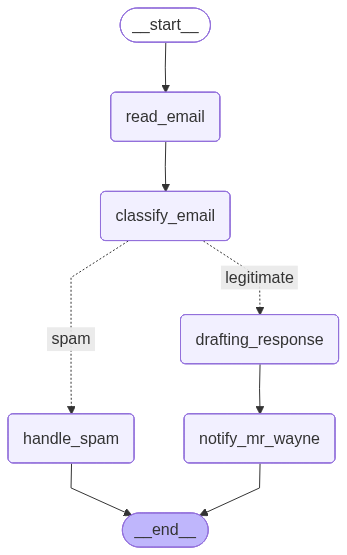

In [21]:
from IPython.display import Image, display

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [22]:
 # Example emails for testing
legitimate_email = {
    "sender": "Joker",
    "subject": "Found you Batman ! ",
    "body": "Mr. Wayne,I found your secret identity ! I know you're batman ! Ther's no denying it, I have proof of that and I'm coming to find you soon. I'll get my revenge. JOKER"
}

spam_email = {
    "sender": "Crypto bro",
    "subject": "The best investment of 2025",
    "body": "Mr Wayne, I just launched an ALT coin and want you to buy some !"
}
# Process legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})

# Process spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
Alfred is processing an email from Joker with subject: Found you Batman ! 
answer :
ham

Sir, you've received an email from Joker.
Subject: Found you Batman ! 

I've prepared a draft response for your review:
--------------------------------------------------
[{'type': 'text', 'text': 'Subject: Re: Found you Batman !\n\nDear Mr. J,\n\nThank you for your correspondence. \n\nMr. Wayne has received your message and has asked me to acknowledge its arrival. He is currently occupied with several pressing philanthropic commitments, but he has noted your request for a meeting. \n\nShould you wish to discuss your claims further, I would suggest we arrange a formal appointment through the proper channels, rather than resorting to unannounced visits, which I’m sure you can appreciate would be quite disruptive to the household.\n\nI shall await your instructions on how you would like to proceed.\n\nRespectfully,\n\nAlfred Pennyworth\nButler to Mr. Bruce Wayne', 'ext

## Step 5: Inspecting Our Mail Sorting Agent with Langfuse 📡

As Alfred fine-tunes the Main Sorting Agent, he's growing weary of debugging its runs. Agents, by nature, are unpredictable and difficult to inspect. But since he aims to build the ultimate Spam Detection Agent and deploy it in production, he needs robust traceability for future monitoring and analysis.

To do this, Alfred can use an observability tool such as [Langfuse](https://langfuse.com/) to trace and monitor the inner steps of the agent.

First, we need to install the necessary dependencies:

In [25]:
%pip install -q langfuse langchain

Note: you may need to restart the kernel to use updated packages.


Next, we set the Langfuse API keys and host address as environment variables. You can get your Langfuse credentials by signing up for [Langfuse Cloud](https://cloud.langfuse.com) or [self-hosting Langfuse](https://langfuse.com/self-hosting).

In [ ]:
# import os

# Get keys for your project from the project settings page: https://cloud.langfuse.com
os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-"
os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-"
os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com"  # 🇪🇺 EU region
# os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com" # 🇺🇸 US region

Now, we configure the [Langfuse `callback_handler`](https://langfuse.com/docs/integrations/langchain/tracing#add-langfuse-to-your-langchain-application).

In [29]:
from langfuse.langchain import CallbackHandler

# Initialize Langfuse CallbackHandler for LangGraph/Langchain (tracing)
langfuse_handler = CallbackHandler()

We then add `config={"callbacks": [langfuse_handler]}` to the invocation of the agents and run them again.

In [30]:
# Process legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke(
    input={
        "email": legitimate_email,
        "is_spam": None,
        "draft_response": None,
        "messages": []
    },
    config={"callbacks": [langfuse_handler]}
)

# Process spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke(
    input={
        "email": spam_email,
        "is_spam": None,
        "draft_response": None,
        "messages": []
    },
    config={"callbacks": [langfuse_handler]}
)


Processing legitimate email...
Alfred is processing an email from Joker with subject: Found you Batman ! 
answer :
ham

Sir, you've received an email from Joker.
Subject: Found you Batman ! 

I've prepared a draft response for your review:
--------------------------------------------------
[{'type': 'text', 'text': 'Subject: Re: Found you Batman !\n\nDear Mr. J,\n\nThank you for your correspondence. \n\nMr. Wayne has received your message and has asked me to acknowledge its arrival. He is currently occupied with several pressing philanthropic commitments, but he has noted your request for a meeting. \n\nShould you wish to discuss your claims further, I would suggest we arrange a formal appointment through the proper channels, rather than resorting to unannounced visits, which I’m sure you can appreciate would be quite disruptive to the household.\n\nI shall await your instructions on how you would like to proceed.\n\nRespectfully,\n\nAlfred Pennyworth\nButler to Mr. Bruce Wayne', 'ext

Alfred is now connected 🔌! The runs from LangGraph are being logged in Langfuse, giving him full visibility into the agent's behavior. With this setup, he's ready to revisit previous runs and refine his Mail Sorting Agent even further.

![Example trace in Langfuse](https://langfuse.com/images/cookbook/huggingface-agent-course/langgraph-trace-legit.png)

_[Public link to the trace with the legit email](https://cloud.langfuse.com/project/cloramnkj0002jz088vzn1ja4/traces/f5d6d72e-20af-4357-b232-af44c3728a7b?timestamp=2025-03-17T10%3A13%3A28.413Z&observation=6997ba69-043f-4f77-9445-700a033afba1)_

![Example trace in Langfuse](https://langfuse.com/images/cookbook/huggingface-agent-course/langgraph-trace-spam.png)

_[Public link to the trace with the spam email](https://langfuse.com/project/cloramnkj0002jz088vzn1ja4/traces/6e498053-fee4-41fd-b1ab-d534aca15f82?timestamp=2025-03-17T10%3A13%3A30.884Z&observation=84770fc8-4276-4720-914f-bf52738d44ba)_
